In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import pyarrow 
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
import statsmodels.formula.api as smf
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline


from sklearn.metrics import root_mean_squared_error as RMSE
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

import joblib


pd.set_option('display.max_columns', None)

In [2]:
df = pd.read_parquet("data/green_tripdata_2021-01.parquet")

numeric_cols = df.select_dtypes(include=np.number).columns
categorical_cols = df.select_dtypes(exclude=np.number).columns

df.head()


,VendorID,lpep_pickup_datetime,lpep_dropoff_datetime,store_and_fwd_flag,RatecodeID,PULocationID,DOLocationID,passenger_count,trip_distance,fare_amount,extra,mta_tax,tip_amount,tolls_amount,ehail_fee,improvement_surcharge,total_amount,payment_type,trip_type,congestion_surcharge
0,2,2021-01-01 00:15:56,2021-01-01 00:19:52,N,1.0,43,151,1.0,1.01,5.5,0.5,0.5,0.00,0.0,None,0.3,6.80,2.0,1.0,0.00
1,2,2021-01-01 00:25:59,2021-01-01 00:34:44,N,1.0,166,239,1.0,2.53,10.0,0.5,0.5,2.81,0.0,None,0.3,16.86,1.0,1.0,2.75
2,2,2021-01-01 00:45:57,2021-01-01 00:51:55,N,1.0,41,42,1.0,1.12,6.0,0.5,0.5,1.00,0.0,None,0.3,8.30,1.0,1.0,0.00
3,2,2020-12-31 23:57:51,2021-01-01 00:04:56,N,1.0,168,75,1.0,1.99,8.0,0.5,0.5,0.00,0.0,None,0.3,9.30,2.0,1.0,0.00
4,2,2021-01-01 00:16:36,2021-01-01 00:16:40,N,2.0,265,265,3.0,0.00,-52.0,0.0,-0.5,0.00,0.0,None,-0.3,-52.80,3.0,1.0,0.00


### Data Cleaning / EDA

In [3]:
def basic_cleaning(df: pd.DataFrame) -> pd.DataFrame:

    df = df.copy()

    # Remove duplicates
    df = df.drop_duplicates()

    return df

def handle_missing_values(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()

    df = df.drop(columns=["ehail_fee"])
    df =df[df.isna().sum(axis=1) < 4] # Drop rows with more than 4 missing values, because we can assume that they are not representative of the population and they can (with imputation) introduce noise in the model
    
    # Handle missing values
    #df["store_and_fwd_flag"] = np.where(df["store_and_fwd_flag"].isna(), "N", df["store_and_fwd_flag"])
    #df["RatecodeID"] = np.where(df["RatecodeID"].isna(), 0, df["RatecodeID"])
    #df["ehail_fee"] = np.where(df["ehail_fee"].isna(), 0, df["ehail_fee"])
    #df["trip_type"] = np.where(df["trip_type"].isna(), 0, df["trip_type"]) # Change Nan to 0, because it is a categorical variable and we can assume that the missing values are from the same category
    #df["congestion_surcharge"] = np.where(df["congestion_surcharge"].isna(), 0, df["congestion_surcharge"])

    return df

def outlier_removal(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()

    df = df[df["passenger_count"] > 0] # Remove passenger counts < 0, because they are not representative of the population

    for col in ["trip_distance", "total_amount"]:
        df = df[df[col] > 0] # Remove rows with non-positive values, because they are not representative of the population and they can introduce noise in the model
        
        Q_range1 = df[[col]].quantile(0.25)
        Q_range2 = df[[col]].quantile(0.75)
        IQR = Q_range2 - Q_range1
        lower_bound = Q_range1  - 3 * IQR
        upper_bound = Q_range2 + 3 * IQR
        df = df[(df[col] >= lower_bound.values[0]) & (df[col] <= upper_bound.values[0])]
        #df = df[(df["trip_distance"] >= lower_bound.values[0]) & (df["trip_distance"] <= upper_bound.values[0])]



    return df

df_clean = basic_cleaning(df)
df_clean = handle_missing_values(df_clean)
df_clean = outlier_removal(df_clean)



(35739, 19)
                            OLS Regression Results                            
Dep. Variable:           total_amount   R-squared:                       0.868
Model:                            OLS   Adj. R-squared:                  0.868
Method:                 Least Squares   F-statistic:                 2.091e+04
Date:                Sun, 01 Mar 2026   Prob (F-statistic):               0.00
Time:                        19:35:39   Log-Likelihood:                -71396.
No. Observations:               28591   AIC:                         1.428e+05
Df Residuals:                   28581   BIC:                         1.429e+05
Df Model:                           9                                         
Covariance Type:            nonrobust                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
Intercept           4.7698    

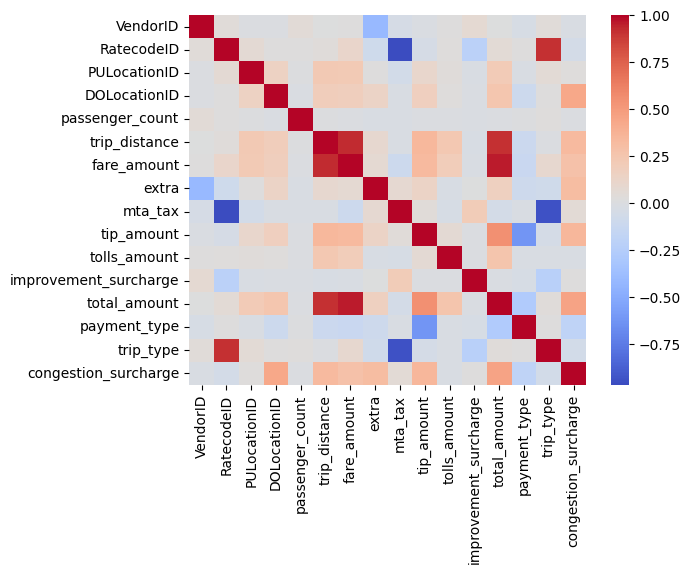

                            OLS Regression Results                            
Dep. Variable:           total_amount   R-squared:                       0.829
Model:                            OLS   Adj. R-squared:                  0.829
Method:                 Least Squares   F-statistic:                 6.935e+04
Date:                Sun, 01 Mar 2026   Prob (F-statistic):               0.00
Time:                        19:35:39   Log-Likelihood:                -75103.
No. Observations:               28591   AIC:                         1.502e+05
Df Residuals:                   28588   BIC:                         1.502e+05
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
Intercept         2.8621      0.150     19.131

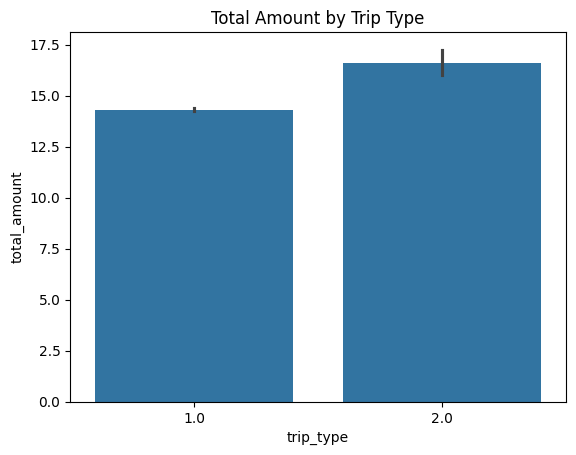

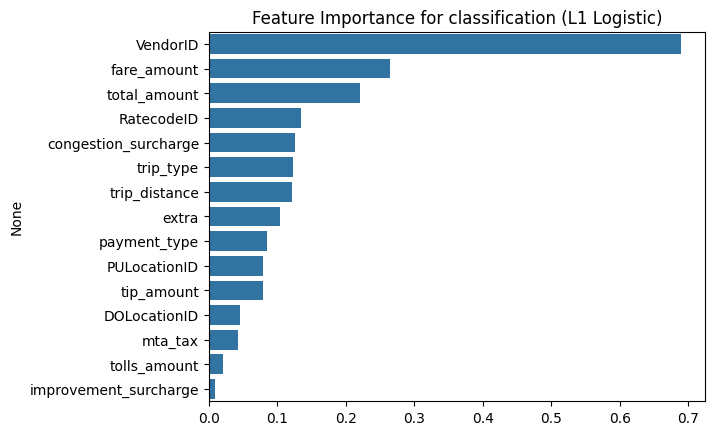

In [4]:
print(df_clean.shape)
df_clean.describe()

# Add quarter and month (for Task 5)
df_clean["quarter"] = df_clean["lpep_pickup_datetime"].dt.quarter
df_clean["month"] = df_clean["lpep_pickup_datetime"].dt.month

# Regression
train_df, test_df = train_test_split(df_clean, test_size=0.2, random_state=42)

model = smf.ols('total_amount ~ VendorID + trip_distance + passenger_count + PULocationID + DOLocationID + RatecodeID + payment_type + trip_type + tolls_amount', train_df)

results = model.fit()
print(results.summary())

corr_matrix = df_clean[numeric_cols].corr()
sns.heatmap(corr_matrix, annot=False, cmap='coolwarm')
plt.show()

model = smf.ols('total_amount ~  trip_distance+ trip_type', train_df)
model
results = model.fit()
print(results.summary())

sns.barplot(x = "trip_type", y = "total_amount", data = df_clean)
plt.title("Total Amount by Trip Type")
plt.show()


# Classification
X = df_clean[numeric_cols].drop(columns=["passenger_count"])
y = df_clean["passenger_count"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

model = LogisticRegression(
    l1_ratio=1,
    solver="saga",
    max_iter=2000,
    random_state=42
)

model.fit(X_train_scaled, y_train)

coef = pd.DataFrame(abs(model.coef_), columns=X.columns)
importance = coef.mean(axis=0).sort_values(ascending=False)

sns.barplot(x=importance.values, y=importance.index)
plt.title("Feature Importance for classification (L1 Logistic)")
plt.show()


### Models


In [5]:
# Regression

selected_featrues = ["trip_distance", "trip_type"]
predictable_feature = "total_amount"

train = train_df[selected_featrues + [predictable_feature]]
test = test_df[selected_featrues + [predictable_feature]]

model = smf.ols(f'{predictable_feature} ~  {" + ".join(selected_featrues)}', train).fit()

preds = model.predict(test[selected_featrues])

print("Root mean squared error:", RMSE(test[predictable_feature], preds))

joblib.dump(model, "regression_model.pkl")

Root mean squared error: 3.3821575893209515


['regression_model.pkl']

In [6]:
# Classification

selected_features = ["VendorID", "trip_type"]
predictable_feature = "passenger_count"

X = df_clean[selected_features].copy()
y = df_clean[predictable_feature].copy()

X_train, x_test, y_train, y_test = train_test_split(X[selected_features], y, test_size=0.2, random_state=42, stratify=y)


pipeline_classification = Pipeline([
    #("scaler", StandardScaler()),
    ("model", LogisticRegression(random_state=42))
])

pipeline_classification.fit(X_train, y_train)
y_pred_pipeline = pipeline_classification.predict(x_test)

print("Accuracy:", accuracy_score(y_test, y_pred_pipeline))
print(classification_report(y_test, y_pred_pipeline))
print(confusion_matrix(y_test, y_pred_pipeline))

joblib.dump(pipeline_classification, "classification_pipeline.pkl")


Accuracy: 0.903329602686066
              precision    recall  f1-score   support

         1.0       0.90      1.00      0.95      6457
         2.0       0.00      0.00      0.00       404
         3.0       0.00      0.00      0.00        60
         4.0       0.00      0.00      0.00        30
         5.0       0.00      0.00      0.00       135
         6.0       0.00      0.00      0.00        62

    accuracy                           0.90      7148
   macro avg       0.15      0.17      0.16      7148
weighted avg       0.82      0.90      0.86      7148

[[6457    0    0    0    0    0]
 [ 404    0    0    0    0    0]
 [  60    0    0    0    0    0]
 [  30    0    0    0    0    0]
 [ 135    0    0    0    0    0]
 [  62    0    0    0    0    0]]


c:\Users\robertis\ml-ops-prac1\venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\robertis\ml-ops-prac1\venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\robertis\ml-ops-prac1\venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape

['classification_pipeline.pkl']

### Task 5

In [7]:
selected_featrues = ["trip_distance", "trip_type", "payment_type"]
predictable_feature = "total_amount"

train = train_df[selected_featrues + [predictable_feature]]
test = test_df[selected_featrues + [predictable_feature]]

model = smf.ols(f'{predictable_feature} ~  {" + ".join(selected_featrues)}', train).fit()

preds = model.predict(test[selected_featrues])

print("Root mean squared error:", RMSE(test[predictable_feature], preds))

#joblib.dump(model, "regression_model.pkl")

Root mean squared error: 3.0964253561387185


In [8]:
selected_features = ["VendorID", "trip_type", "PULocationID"]
predictable_feature = "passenger_count"

X = df_clean[selected_features].copy()
y = df_clean[predictable_feature].copy()

X_train, x_test, y_train, y_test = train_test_split(X[selected_features], y, test_size=0.2, random_state=42, stratify=y)


pipeline_classification = Pipeline([
    #("scaler", StandardScaler()),
    ("model", LogisticRegression(random_state=42))
])

pipeline_classification.fit(X_train, y_train)
y_pred_pipeline = pipeline_classification.predict(x_test)

print("Accuracy:", accuracy_score(y_test, y_pred_pipeline))
print(classification_report(y_test, y_pred_pipeline))
print(confusion_matrix(y_test, y_pred_pipeline))

Accuracy: 0.903329602686066
              precision    recall  f1-score   support

         1.0       0.90      1.00      0.95      6457
         2.0       0.00      0.00      0.00       404
         3.0       0.00      0.00      0.00        60
         4.0       0.00      0.00      0.00        30
         5.0       0.00      0.00      0.00       135
         6.0       0.00      0.00      0.00        62

    accuracy                           0.90      7148
   macro avg       0.15      0.17      0.16      7148
weighted avg       0.82      0.90      0.86      7148

[[6457    0    0    0    0    0]
 [ 404    0    0    0    0    0]
 [  60    0    0    0    0    0]
 [  30    0    0    0    0    0]
 [ 135    0    0    0    0    0]
 [  62    0    0    0    0    0]]


c:\Users\robertis\ml-ops-prac1\venv\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
c:\Users\robertis\ml-ops-prac1\venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\robertis\ml-ops-prac1\venv\Lib\site-packages\sklearn\metr